
RL tradability env v2 -- state enrichment.

Adds to the observation (over v1):
  - unrealized PnL of the open position, scaled by trailing HA-range (regime-invariant)
  - bars-in-position (the RL's OWN learned segment duration; NOT the JMA g)
Observation width 259 -> 261, so v1's saved model will NOT load. Fresh train required.

Eval extended to emit reward-shaping diagnostics:
  - per-segment DURATION distribution (targets the quick-trade penalty)
  - per-segment MFE - realized (give-back; targets the give-back penalty)

Fills still HA next-Open. Reward still raw PnL - COST (NO shaping yet).

https://claude.ai/chat/6e84cdd1-de9d-4f59-9967-df1b3a1620d4

In [1]:
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3.common.vec_env import DummyVecEnv
from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker

In [2]:
# ----------------------------- config -----------------------------
INPUT       = "ha-2sec-full-rl-v4.pqt"
FEATS = ["jmaD1", "haColour", "jmaD2", "rsxLast", "rsxLastD1", "rsxLastD2", "cfbD1",
         "haBody", "candleCross", "wickAsym", "haWickTop", "haWickBott", "bodyRange",
         "dBody_3", "dWickTopR_3", "dWickBotR_3"]
PRICE_COL   = "Open"
LOOKBACK    = 16
COST        = 1.57
TEST_FRAC   = 0.20
N_ENVS      = 8
TOTAL_STEPS = 3_000_000
MIN_BARS    = LOOKBACK + 5
SCALE_N     = 30               # trailing bars for HA-range scale on unrealized PnL
QUICK_PENALTY = 2.0

ACT_STAYOUT, ACT_LONG, ACT_SHORT, ACT_HOLD, ACT_EXIT = 0, 1, 2, 3, 4

'''
 0   timestamp    datetime64[us]
 1   Open         float64       
 2   High         float64       
 3   Low          float64       
 4   Close        float64       
 5   jma          float64       
 6   jmaD1        float64       
 7   haColour     int8          
 8   jmaD2        float64       
 9   rsxLast      float64       
 10  rsxLastD1    float64       
 11  rsxLastD2    float64       
 12  cfbD1        float64       
 13  haBody       float64       
 14  candleCross  int8          
 15  wickAsym     float64       
 16  haWickTop    float64       
 17  haWickBott   float64       
 18  bodyRange    float64       
 19  dBody_3      float64       
 20  dWickTopR_3  float64       
 21  dWickBotR_3  float64       
 22  date         datetime64[us]
 '''

'\n 0   timestamp    datetime64[us]\n 1   Open         float64       \n 2   High         float64       \n 3   Low          float64       \n 4   Close        float64       \n 5   jma          float64       \n 6   jmaD1        float64       \n 7   haColour     int8          \n 8   jmaD2        float64       \n 9   rsxLast      float64       \n 10  rsxLastD1    float64       \n 11  rsxLastD2    float64       \n 12  cfbD1        float64       \n 13  haBody       float64       \n 14  candleCross  int8          \n 15  wickAsym     float64       \n 16  haWickTop    float64       \n 17  haWickBott   float64       \n 18  bodyRange    float64       \n 19  dBody_3      float64       \n 20  dWickTopR_3  float64       \n 21  dWickBotR_3  float64       \n 22  date         datetime64[us]\n '

In [3]:
# ----------------------------- data -----------------------------
df = pd.read_parquet(INPUT)
feat = df[FEATS].to_numpy(np.float32)
openp = df[PRICE_COL].to_numpy(np.float64)
dates = df["date"].values

In [4]:
harange = (df["haBody"].to_numpy(np.float64)
           + df["haWickTop"].to_numpy(np.float64)
           + df["haWickBott"].to_numpy(np.float64))
scale = pd.Series(harange).groupby(dates).transform(
    lambda s: s.rolling(SCALE_N, min_periods=5).mean()).to_numpy()
scale = np.where(np.isnan(scale) | (scale < 1e-6), np.nanmedian(harange), scale)

tmp = pd.DataFrame({"date": dates}); tmp["idx"] = np.arange(len(tmp))
agg = tmp.groupby("date")["idx"].agg(["first", "last"])
all_days = [d for d in agg.index if agg.loc[d, "last"] - agg.loc[d, "first"] + 1 >= MIN_BARS]
all_days = sorted(all_days)
n_test = int(len(all_days) * TEST_FRAC)
train_days = all_days[:-n_test]
test_days = all_days[-n_test:]
bounds = {d: (int(agg.loc[d, "first"]), int(agg.loc[d, "last"])) for d in all_days}
print(f"{len(all_days)} usable days -> train {len(train_days)}  test {len(test_days)}")
print(f"train {train_days[0]}..{train_days[-1]}   test {test_days[0]}..{test_days[-1]}")

tr_mask = df["date"].isin(set(train_days)).to_numpy()
mu = feat[tr_mask].mean(0); sd = feat[tr_mask].std(0) + 1e-8
feat = (feat - mu) / sd

1158 usable days -> train 927  test 231
train 2022-01-03 00:00:00..2025-08-04 00:00:00   test 2025-08-05 00:00:00..2026-06-26 00:00:00


In [5]:
# ----------------------------- environment -----------------------------
class TradingEnv(gym.Env):
    def __init__(self, day_list):
        super().__init__()
        self.day_list = list(day_list)
        self.action_space = spaces.Discrete(5)
        self.observation_space = spaces.Box(-np.inf, np.inf,
                                            shape=(LOOKBACK * len(FEATS) + 5, ), dtype=np.float32)
        self.rng = np.random.default_rng()

    def _set_day(self, d):
        self.s, self.e = bounds[d]
        self.i = self.s + LOOKBACK - 1
        self.pos = 0
        self.entry_i = -1
        self.entry_px = 0.0
        self.bars_in = 0
        self.mfe = 0.0            # max favorable excursion of open segment (for eval only)

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        d = (options or {}).get("day") or self.rng.choice(self.day_list)
        self._set_day(d)
        return self._obs(), {}

    def _obs(self):
        w = feat[self.i - LOOKBACK + 1: self.i + 1].reshape(-1)
        p = np.zeros(3, np.float32); p[self.pos + 1] = 1.0
        if self.pos != 0:
            #upnl = self.pos * (openp[self.i] - self.entry_px) / scale[self.i]
            upnl = np.tanh(self.pos * (openp[self.i] - self.entry_px) / scale[self.i] / 10.0)
            bin_ = self.bars_in / 100.0
        else:
            upnl = 0.0; bin_ = 0.0
        extra = np.array([upnl, bin_], np.float32)
        return np.concatenate([w, p, extra]).astype(np.float32)

    def action_masks(self):
        if self.pos == 0:
            return np.array([True, True, True, False, False])
        return np.array([False, False, False, True, True])

    def step(self, a):
        held = self.pos
        move = openp[self.i + 1] - openp[self.i]
        reward = held * move
        entered = exited = 0
        seg_dur = seg_giveback = -1.0                      # emitted only on a closing bar

        if a == ACT_LONG and self.pos == 0:
            self.pos = 1; self.entry_i = self.i + 1; self.entry_px = openp[self.i + 1]
            self.bars_in = 0; self.mfe = 0.0; reward -= COST; entered = 1
        elif a == ACT_SHORT and self.pos == 0:
            self.pos = -1; self.entry_i = self.i + 1; self.entry_px = openp[self.i + 1]
            self.bars_in = 0; self.mfe = 0.0; reward -= COST; entered = 1
        elif a == ACT_EXIT and self.pos != 0:
            realized = self.pos * (openp[self.i + 1] - self.entry_px)
            seg_dur = float(self.bars_in); seg_giveback = float(self.mfe - realized)
            if seg_dur <= 2:
                reward -= QUICK_PENALTY * (3 - seg_dur)
            self.pos = 0; self.bars_in = 0; reward -= COST; exited = 1            
        # ACT_HOLD / ACT_STAYOUT: no change, no cost

        self.i += 1
        if self.pos != 0:
            self.bars_in += 1
            upnl_now = self.pos * (openp[self.i] - self.entry_px)
            if upnl_now > self.mfe:
                self.mfe = upnl_now

        terminated = self.i >= self.e

        if terminated and self.pos != 0:
            realized = self.pos * (openp[self.i] - self.entry_px)
            seg_dur = float(self.bars_in); seg_giveback = float(self.mfe - realized)
            if seg_dur <= 2:
                reward -= QUICK_PENALTY * (3 - seg_dur)
            reward -= COST; exited = 1; self.pos = 0
            
        info = {"entered": entered, "exited": exited, "in_pos": int(held != 0),
                "seg_dur": seg_dur, "seg_giveback": seg_giveback}
        return self._obs(), float(reward), terminated, False, info

def make_env(day_list):
    def _init():
        return ActionMasker(TradingEnv(day_list), lambda env: env.action_masks())
    return _init

In [6]:
# ----------------------------- correctness check -----------------------------
def _check_env():
    e = TradingEnv(train_days); d = train_days[len(train_days)//2]
    e.reset(options={"day": d}); s, en = bounds[d]
    total = 0.0; done = False; first = True
    while not done:
        a = ACT_LONG if first else ACT_HOLD; first = False
        _, r, done, _, _ = e.step(a); total += r
    bh = (openp[en] - openp[s + LOOKBACK]) - 2 * COST
    print(f"[env check] always-long PnL {total:.4f}  vs  HA buy&hold {bh:.4f}  diff {abs(total-bh):.6f}")
    e.reset(options={"day": d}); tot0 = 0.0; done = False
    while not done:
        _, r, done, _, _ = e.step(ACT_STAYOUT); tot0 += r
    print(f"[env check] always-stay-out PnL {tot0:.6f}  (must be 0)")

_check_env()

[env check] always-long PnL -45.5375  vs  HA buy&hold -45.5375  diff 0.000000
[env check] always-stay-out PnL 0.000000  (must be 0)


In [7]:
# ----------------------------- train -----------------------------
venv = DummyVecEnv([make_env(train_days) for _ in range(N_ENVS)])
model = MaskablePPO("MlpPolicy", venv, device="cpu", verbose=0, # auto verbose=1 - trains for 35 min
                    n_steps=8192, batch_size=256, n_epochs=10,
                    gamma=0.99, gae_lambda=0.95, clip_range=0.2,
                    ent_coef=0.01, learning_rate=3e-4,
                    policy_kwargs=dict(net_arch=[256, 256]))
print(f"\ntraining MaskablePPO for {TOTAL_STEPS:,} steps on {N_ENVS} envs...")
model.learn(total_timesteps=TOTAL_STEPS, progress_bar=True)

Using cuda device


Output()


training MaskablePPO for 3,000,000 steps on 8 envs...
------------------------------
| time/              |       |
|    fps             | 2401  |
|    iterations      | 1     |
|    time_elapsed    | 27    |
|    total_timesteps | 65536 |
------------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1727        |
|    iterations           | 2           |
|    time_elapsed         | 75          |
|    total_timesteps      | 131072      |
| train/                  |             |
|    approx_kl            | 0.018154137 |
|    clip_fraction        | 0.413       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.851      |
|    explained_variance   | -0.00399    |
|    learning_rate        | 0.0003      |
|    loss                 | 25.4        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0513     |
|    value_loss           | 83          |
--------------

In [9]:
model.save("rl_seg_v2a-quickpenalty-2.0")

In [8]:
# ----------------------------- evaluate -----------------------------
from tqdm import tqdm

model.policy.set_training_mode(False)
model.policy.to("cpu")          # single-obs inference is FASTER on CPU (no GPU transfer overhead)

def run(policy, days):
    env = TradingEnv(days)
    tot_r = n_ent = n_pos = n_bar = 0.0
    durs = []; gbs = []
    #for d in days:
    for d in tqdm(days, desc=policy):
    
        obs, _ = env.reset(options={"day": d}); done = False
        while not done:
            mask = env.action_masks()
            if policy == "random":
                valid = np.where(mask)[0]; a = int(np.random.choice(valid))
            else:
                a, _ = model.predict(obs, action_masks=mask, deterministic=True); a = int(a)
            obs, r, done, _, info = env.step(a)
            tot_r += r; n_ent += info["entered"]; n_pos += info["in_pos"]; n_bar += 1
            if info["seg_dur"] >= 0:
                durs.append(info["seg_dur"]); gbs.append(info["seg_giveback"])
    nd = len(days); durs = np.array(durs) if durs else np.array([0.0])
    gbs = np.array(gbs) if gbs else np.array([0.0])
    return dict(rew_day=tot_r / nd, trades_day=n_ent / nd,
                dur=n_pos / max(n_ent, 1), pct_pos=n_pos / n_bar,
                dur_med=np.median(durs), dur_p10=np.percentile(durs, 10),
                frac_short=float((durs <= 2).mean()), giveback_med=float(np.median(gbs)))

print(f'QUICK_PENALTY: {QUICK_PENALTY}')

print("-- starting eval: train days --")
tr = run("model", train_days[-len(test_days):])

print("-- starting eval: test days --")
te = run("model", test_days)

print("-- starting eval: random --")
rnd = run("random", test_days)

print("\n=== results (per-day) ===")
def show(name, r):
    print(f"  {name:14} rew/day {r['rew_day']:9.2f}  trades/day {r['trades_day']:6.2f}  "
          f"avg_dur {r['dur']:5.1f}  in_pos {r['pct_pos']:.1%}")
    print(f"  {'':14} seg_dur med {r['dur_med']:5.1f}  p10 {r['dur_p10']:4.1f}  "
          f"frac<=2bars {r['frac_short']:.1%}  giveback med {r['giveback_med']:6.2f}")
show("train (recent)", tr); show("test (held-out)", te); show("random (test)", rnd)

print("\n=== diagnosis ===")
if te["trades_day"] < 0.5 and tr["trades_day"] < 0.5:
    print("  SITS FLAT.")
elif tr["rew_day"] > 2 * max(te["rew_day"], 0.01) and te["rew_day"] <= rnd["rew_day"] * 1.1:
    print("  MEMORIZES: strong on train, ~random on held-out.")
elif te["rew_day"] > rnd["rew_day"] + abs(rnd["rew_day"]) * 0.1:
    print("  GENERALIZES (weak): held-out beats random.")
else:
    print("  TRADES BUT NO EDGE: test ~ random.")
print("  shaping targets: frac<=2bars (quick-trade), giveback med (give-back).")

QUICK_PENALTY: 2.0
-- starting eval: train days --


model: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 231/231 [17:12<00:00,  4.47s/it]


-- starting eval: test days --


model: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 231/231 [15:47<00:00,  4.10s/it]


-- starting eval: random --


random: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 231/231 [01:05<00:00,  3.55it/s]



=== results (per-day) ===
  train (recent) rew/day  -3577.58  trades/day 922.35  avg_dur  11.0  in_pos 82.7%
                 seg_dur med   3.0  p10  1.0  frac<=2bars 46.4%  giveback med   0.16
  test (held-out) rew/day  -4489.06  trades/day 1134.82  avg_dur   8.6  in_pos 79.3%
                 seg_dur med   3.0  p10  1.0  frac<=2bars 48.8%  giveback med   0.14
  random (test)  rew/day -19879.52  trades/day 3524.67  avg_dur   2.0  in_pos 57.1%
                 seg_dur med   1.0  p10  1.0  frac<=2bars 75.1%  giveback med   0.09

=== diagnosis ===
  GENERALIZES (weak): held-out beats random.
  shaping targets: frac<=2bars (quick-trade), giveback med (give-back).


In [10]:
"""
plot_day("2025-03-14") -- SC-style visual validation of the RL segmentation.

Replays the saved MaskablePPO policy over one day and renders:
  - HA candlesticks (Open/High/Low/Close)
  - jma line
  - the policy's 5 actions as distinct markers:
      long entry   green triangle-up      (below bar)
      short entry  red   triangle-down    (above bar)
      exit         black x                (at close)
      hold         faint blue dot         (at close, small)
      stay-out     faint grey dot         (at low, small)

Assumes in the notebook there is already:
  df        -- full parquet incl. Open/High/Low/Close, jma, date, and the 16 FEATS
  feat      -- normalized feature matrix used in training (same normalization!)
  bounds    -- {date: (first_idx, last_idx)}
  TradingEnv, FEATS, LOOKBACK, ACT_* constants from the env script
  model     -- loaded via: model = MaskablePPO.load("rl_seg_v1")

If replaying in a fresh kernel, rebuild feat/bounds with the SAME train-day
normalization as training, or the policy sees shifted inputs and marks garbage.
"""
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

ACTION_STYLE = {
    0: dict(name="stay-out", symbol="circle",        color="rgba(32,32,32,1)", size=5),
    1: dict(name="long",     symbol="triangle-up",   color="#00b300",                size=11),
    2: dict(name="short",    symbol="triangle-down", color="#e60000",                size=11),
    3: dict(name="hold",     symbol="circle",        color="rgba(30,100,220,0.6)",  size=5),
    4: dict(name="exit",     symbol="x",             color="#000000",                size=6),
}

def plot_day(date, jma_col="jma", show_holds=True, height=750):
    d = pd.Timestamp(date)
    if d not in bounds:
        avail = sorted(bounds.keys())
        raise ValueError(f"{date} not in data. range {avail[0]}..{avail[-1]}")
    s, e = bounds[d]

    # ---- replay policy over the day, greedy, masked ----
    env = TradingEnv([d])
    obs, _ = env.reset(options={"day": d})
    acts = np.full(e - s + 1, -1, np.int8)         # per-bar action, indexed from s
    done = False
    while not done:
        i_rel = env.i - s                          # decision bar (relative)
        mask = env.action_masks()
        a, _ = model.predict(obs, action_masks=mask, deterministic=True)
        acts[i_rel] = int(a)
        obs, r, done, _, info = env.step(int(a))

    day = df.iloc[s:e + 1]
    ts = pd.to_datetime(day["timestamp"])

    fig = make_subplots(rows=1, cols=1)
    fig.add_trace(go.Candlestick(
        x=ts, open=day["Open"], high=day["High"], low=day["Low"], close=day["Close"],
        name="HA", increasing_line_color="#26a69a", decreasing_line_color="#ef5350",
        line=dict(width=1), opacity=0.9))
    if jma_col in day.columns:
        fig.add_trace(go.Scatter(x=ts, y=day[jma_col], name="jma",
                                 line=dict(color="#0000ff", width=1.6)))
    else:
        print(f"[warn] '{jma_col}' not in df; candidates: "
              f"{[c for c in day.columns if 'jma' in c.lower()]}")

    lo, hi = day["Low"].values, day["High"].values
    pad = (hi - lo).mean() * 0.6
    for code, st in ACTION_STYLE.items():
        if not show_holds and code in (0, 3):
            continue
        m = acts == code
        if not m.any():
            continue
        if code == 1:   y = lo[m] - pad            # long entry below bar
        elif code == 2: y = hi[m] + pad            # short entry above bar
        elif code == 4: y = day["Close"].values[m] # exit at close
        elif code == 3: y = day["Close"].values[m] # hold at close
        else:           y = lo[m] - pad * 0.5      # stay-out at low
        fig.add_trace(go.Scatter(
            x=ts[m], y=y, mode="markers", name=st["name"],
            marker=dict(symbol=st["symbol"], color=st["color"], size=st["size"])))

    n_long = int((acts == 1).sum()); n_short = int((acts == 2).sum())
    n_exit = int((acts == 4).sum()); pct_in = float(np.isin(acts, (1, 2, 3)).mean())
    fig.update_layout(
        title=f"{pd.Timestamp(date).date()}   longs {n_long}  shorts {n_short}  "
              f"exits {n_exit}  in-segment {pct_in:.0%}",
        height=height, xaxis_rangeslider_visible=False,
        legend=dict(orientation="h", y=1.02, x=0),
        margin=dict(l=40, r=20, t=60, b=30))
    fig.show()
    return acts                                     # per-bar actions if you want to inspect

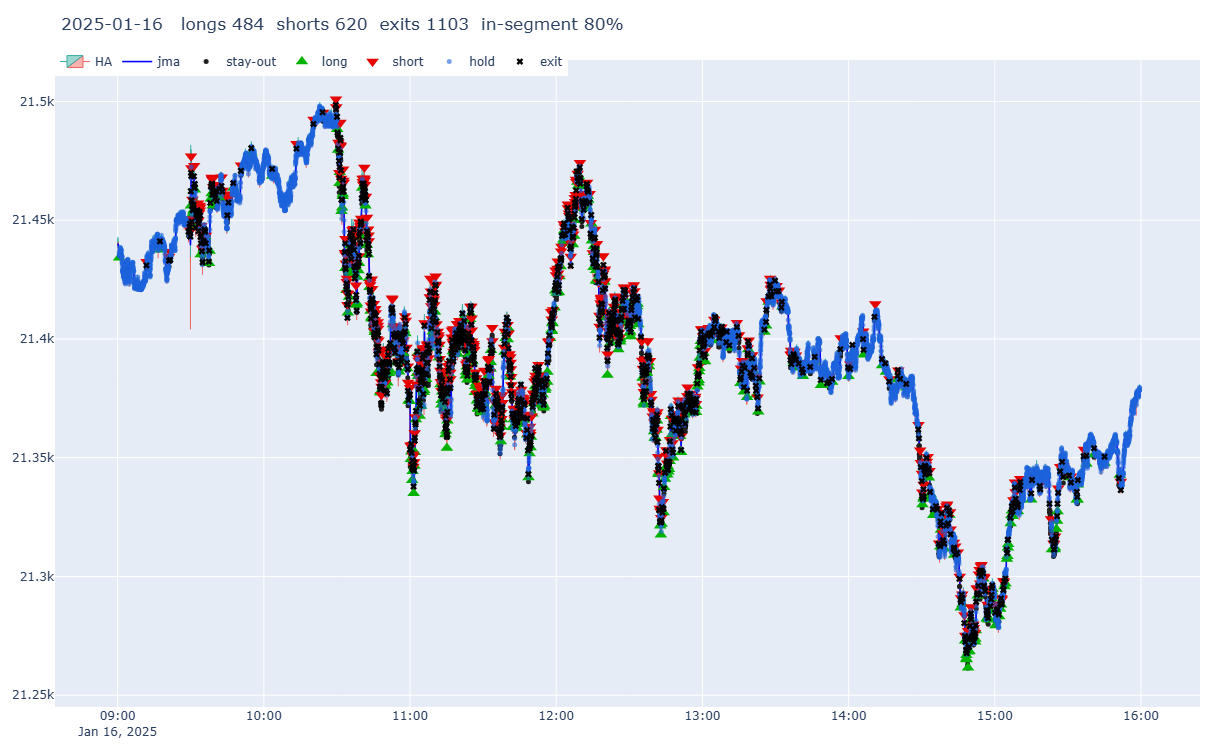

[-1 -1 -1 ...  3  3 -1]


In [11]:
acts = plot_day("2025-01-16")
print(acts)